1. Develop a program to create histograms for all numerical features and analyze the distribution of each feature. Generate box plots for all numerical features and identify any outliers. Use California Housing dataset.

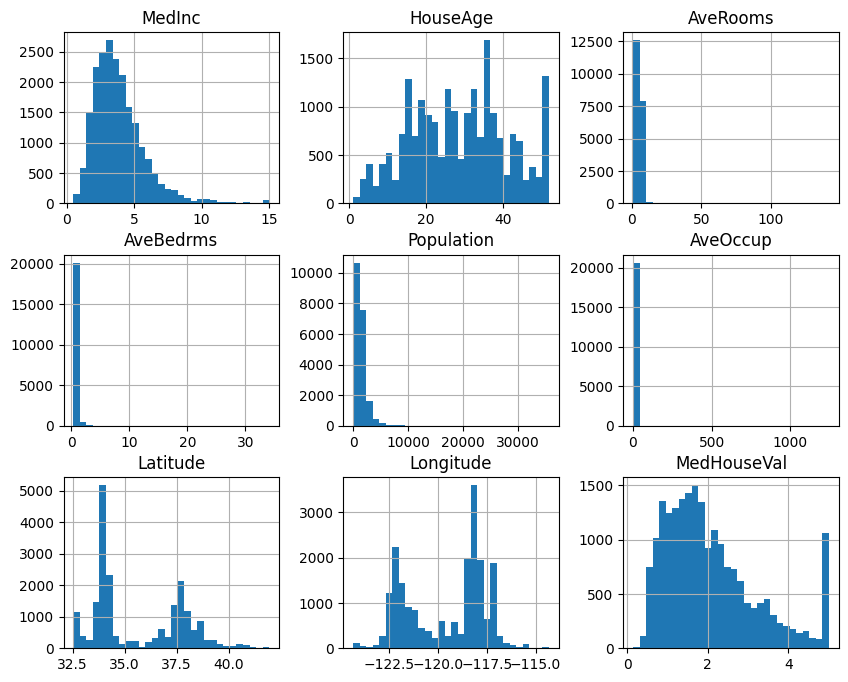

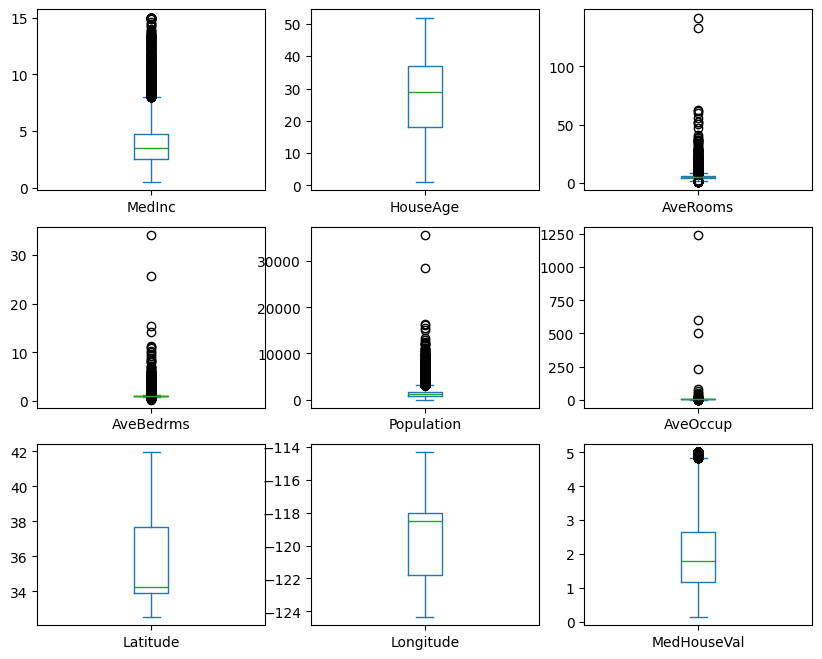

Outliers detected per feature:
MedInc : 681
HouseAge : 0
AveRooms : 511
AveBedrms : 1424
Population : 1196
AveOccup : 711
Latitude : 0
Longitude : 0
MedHouseVal : 1071


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

df = fetch_california_housing(as_frame=True).frame
df.hist(figsize=(10,8), bins=30)
plt.show()
df.plot(kind='box', subplots=True, layout=(3,3), figsize=(10,8))
plt.show()

print("Outliers detected per feature:")
for c in df.columns:
    Q1,Q3 = df[c].quantile([0.25,0.75])
    IQR = Q3-Q1
    out = df[(df[c] < Q1-1.5*IQR) | (df[c] > Q3+1.5*IQR)]
    print(c,":",len(out))

2. Develop a program to Compute the correlation matrix to understand the relationships between pairs of features. Visualize the correlation matrix using a heatmap to know which variables have strong positive/negative correlations. Create a pair plot to visualize pairwise relationships between features. Use California Housing dataset.

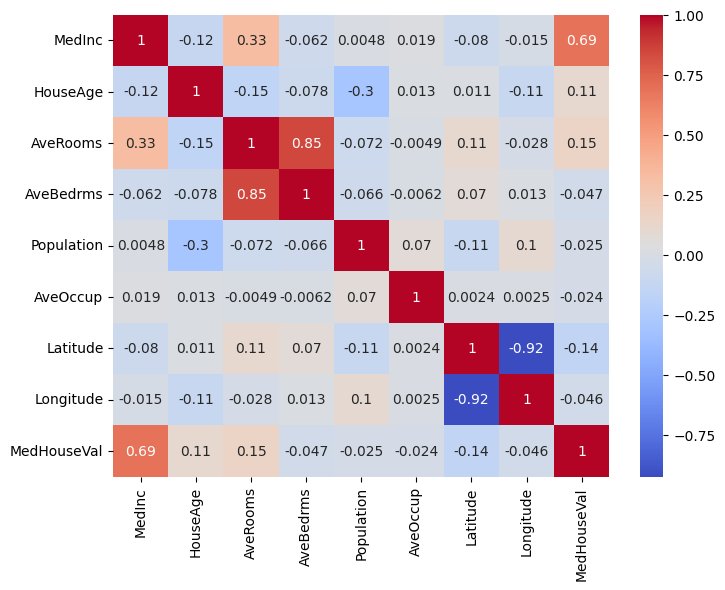

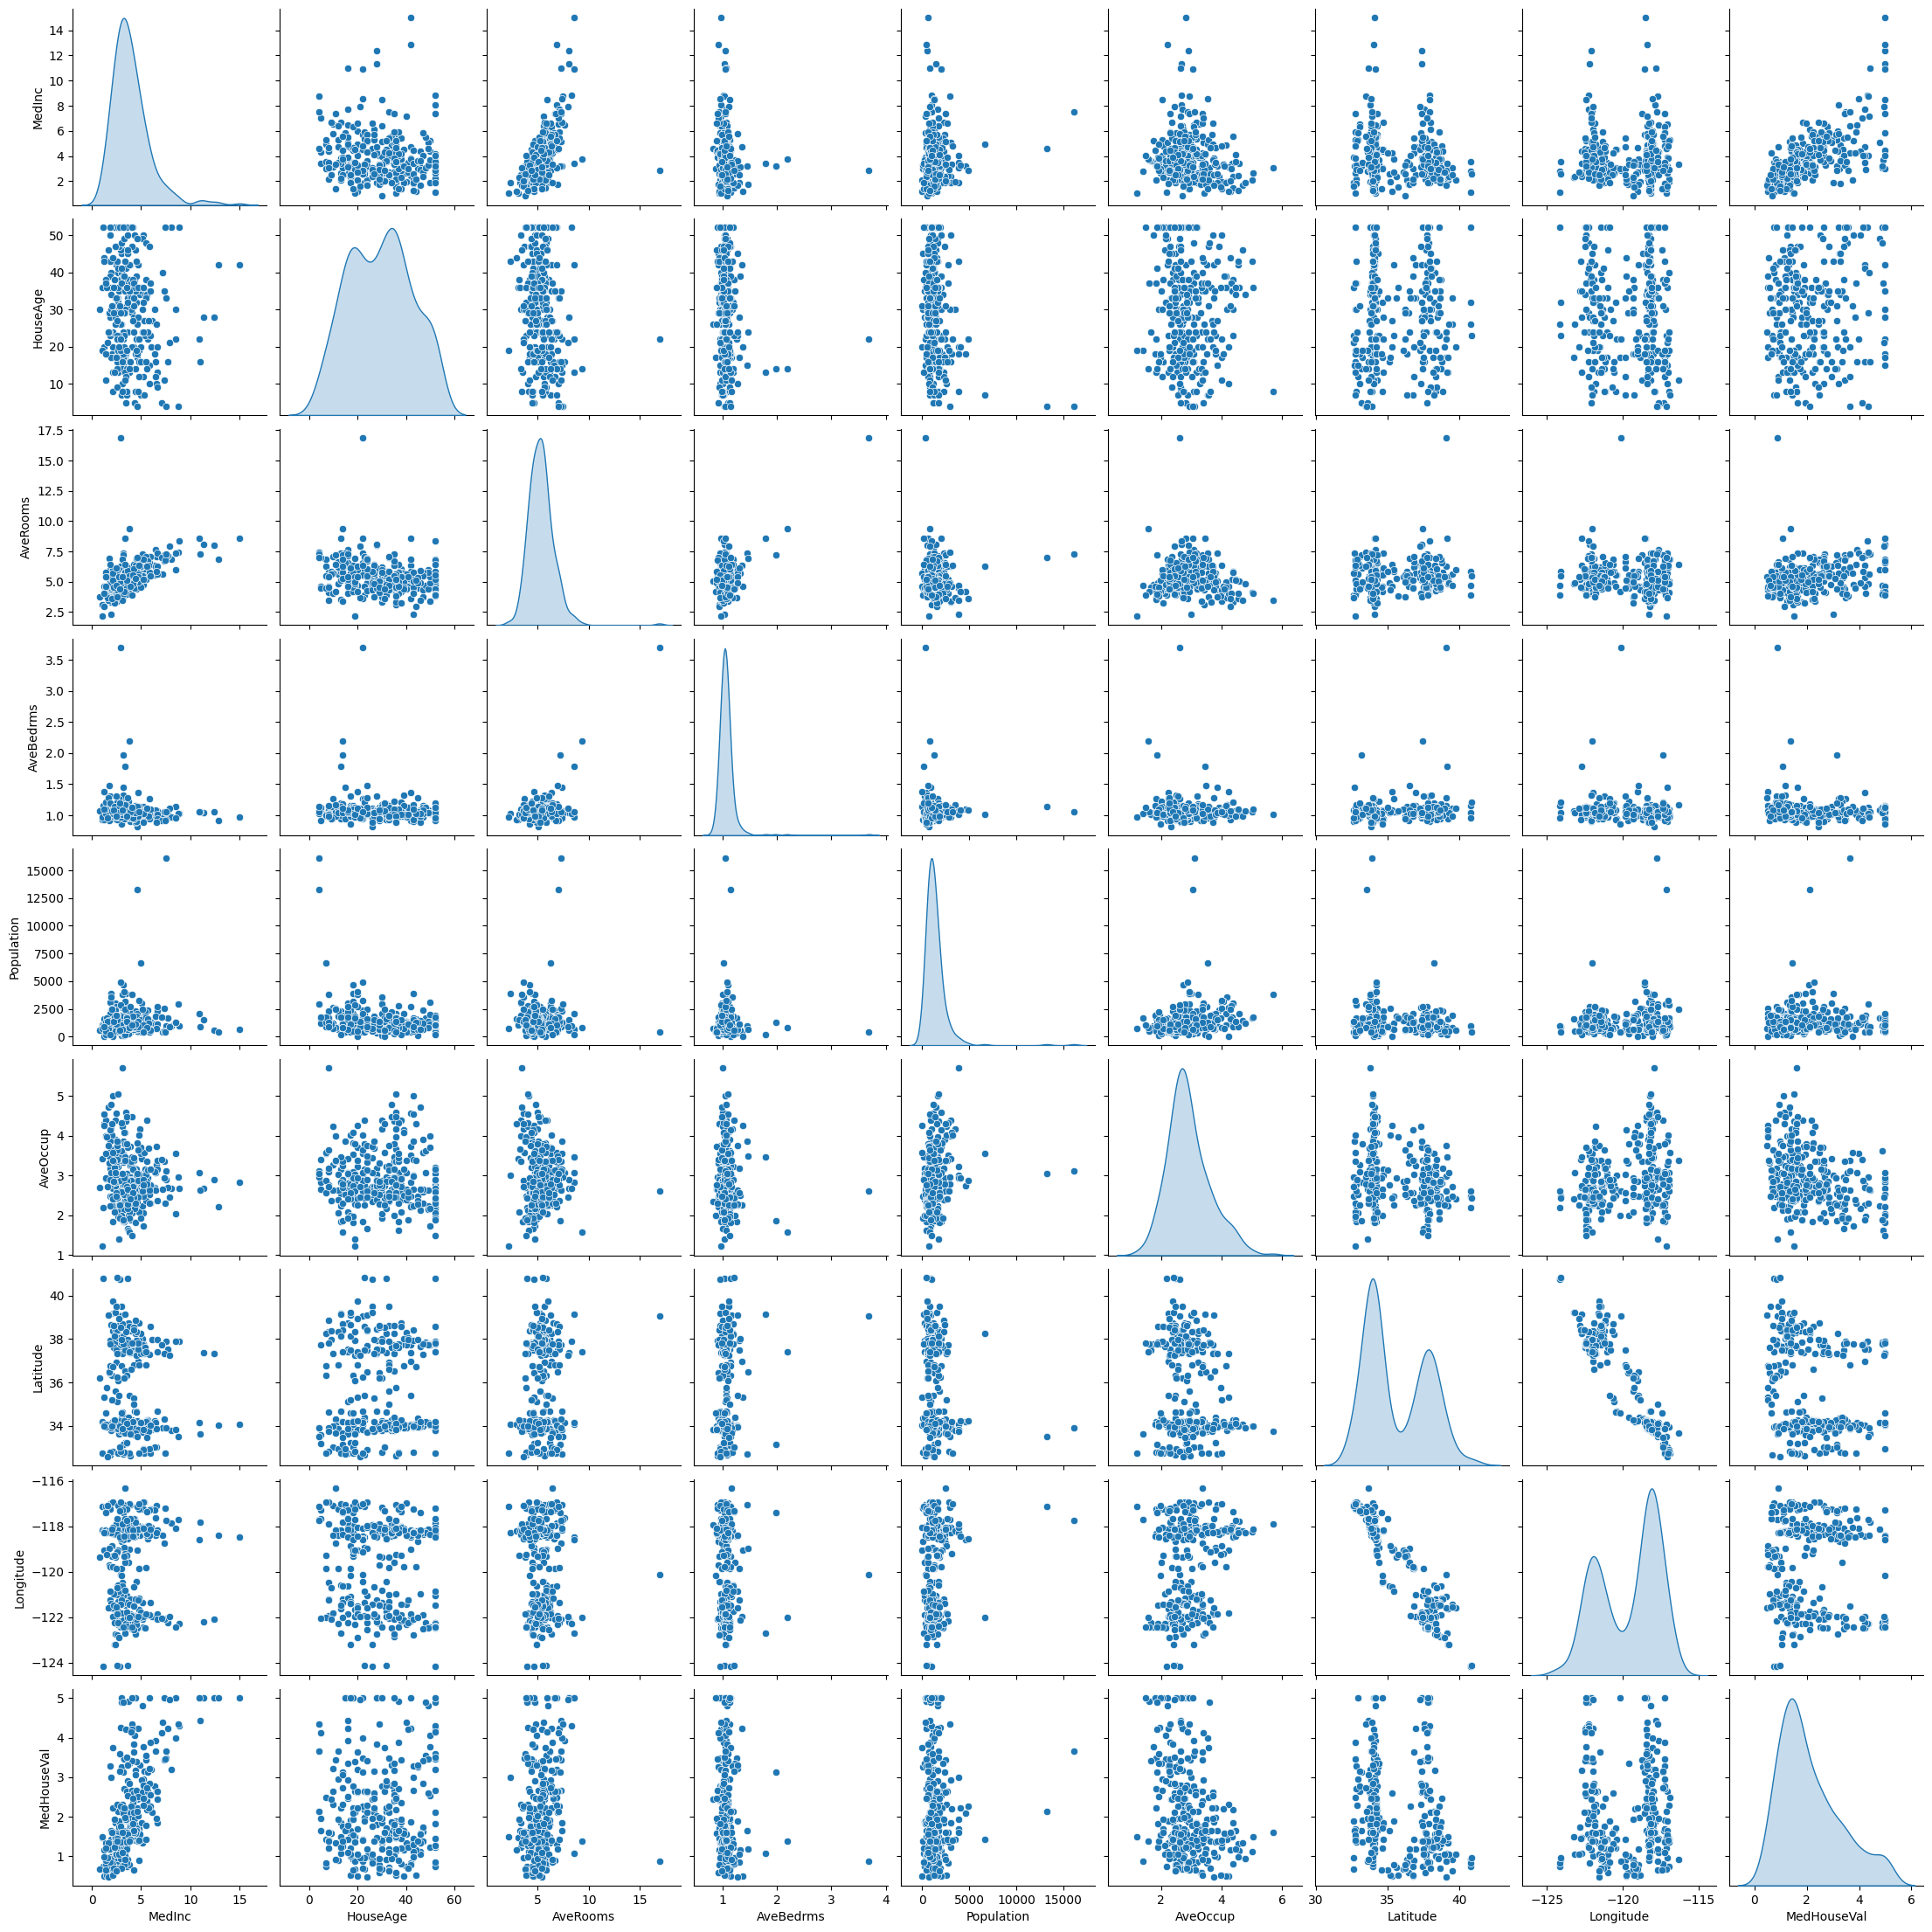

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

df = fetch_california_housing(as_frame=True).frame
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()
sns.pairplot(df.sample(300), diag_kind='kde')
plt.show()

3. Develop a program to implement Principal Component Analysis (PCA) for reducing the dimensionality of the Iris dataset from 4 features to 2.

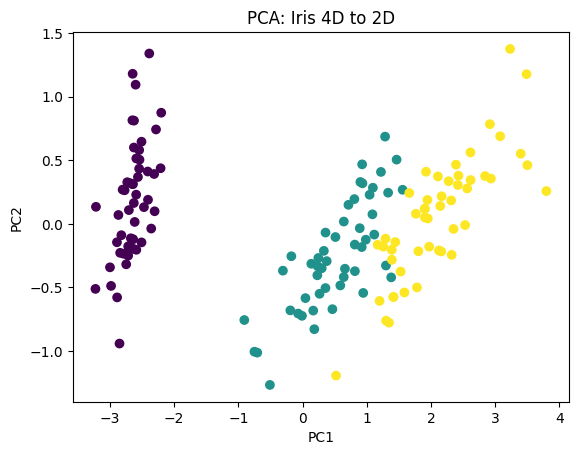

Variance Ratio: [0.92461872 0.05306648]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

iris = load_iris()
X,y = iris.data, iris.target
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: Iris 4D to 2D")
plt.show()
print("Variance Ratio:", pca.explained_variance_ratio_)

4. For a given set of training data examples stored in a .CSV file, implement and demonstrate the Find-S algorithm to output a description of the set of all hypotheses consistent with the training examples.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("training_data.csv")
print("Training data:\n",df)
X = np.array(df.iloc[:,:-1])
y = np.array(df.iloc[:,-1])
h = X[y=='Yes'][0].copy()

for x in X[y=='Yes']:
    h[np.where(x!=h)]='?'
print("Final hypothesis:",list(h))

Training data:
     Outlook Temperature Humidity  Windy PlayTennis
0     Sunny         Hot     High  False         No
1     Sunny         Hot     High   True         No
2  Overcast         Hot     High  False        Yes
3      Rain        Cold     High  False        Yes
4      Rain        Cold     High   True         No
5  Overcast         Hot     High   True        Yes
6     Sunny         Hot     High  False         No
Final hypothesis: ['?', '?', 'High', '?']


5. Develop a program to implement k-Nearest Neighbour algorithm to classify the randomly generated 100 values of x in the range of [0,1]. Perform the following based on dataset generated.

a) Label the first 50 points {x1,……,x50} as follows: if (xi ≤ 0.5), then xi ∊ Class1, else xi ∊ Class1

b) Classify the remaining points, x51,……,x100 using KNN. Perform this for k=1,2,3,4,5,20,30

k = 1 Class1: 25 Class2: 25
k = 2 Class1: 25 Class2: 25
k = 3 Class1: 24 Class2: 26
k = 4 Class1: 24 Class2: 26
k = 5 Class1: 24 Class2: 26
k = 20 Class1: 24 Class2: 26
k = 30 Class1: 25 Class2: 25


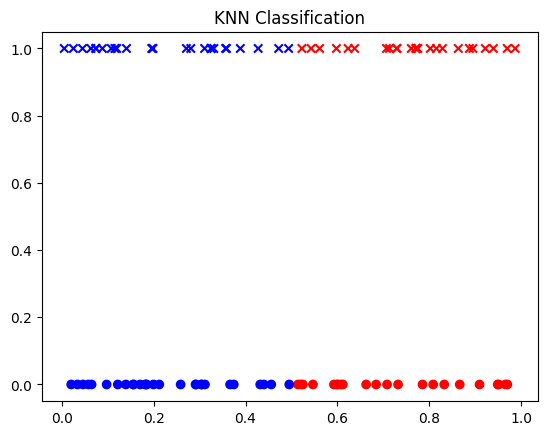

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)
x = np.random.rand(100)
tr_x, ts_x = x[:50], x[50:]
tr_y = ["Class1" if v<=0.5 else "Class2" for v in tr_x]
for k in [1,2,3,4,5,20,30]:
    preds=[]
    for p in ts_x:
        idx = np.argsort(np.abs(tr_x-p))[:k]
        lab = [tr_y[i] for i in idx]
        preds.append(Counter(lab).most_common(1)[0][0])
    print("k =",k,"Class1:",preds.count("Class1"),"Class2:",preds.count("Class2"))

plt.scatter(tr_x,[0]*50,c=['b' if l=='Class1' else 'r' for l in tr_y])
plt.scatter(ts_x,[1]*50,c=['b' if p=='Class1' else 'r' for p in preds],marker='x')
plt.title("KNN Classification")
plt.show()

6. Implement the non-parametric Locally Weighted Regression algorithm in order to fit data points. Select appropriate data set for your experiment and draw graphs.

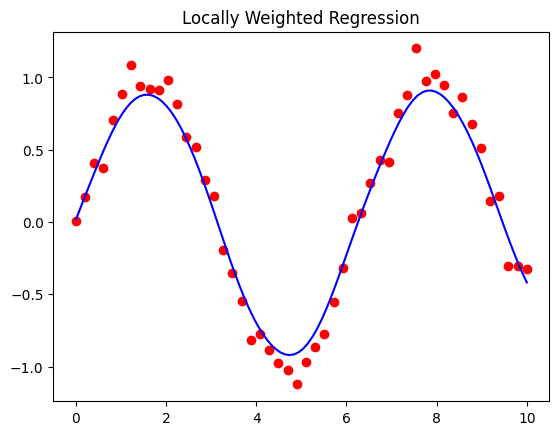

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.linspace(0,10,50)
y = np.sin(X) + np.random.normal(0,0.1,50)
X_mat = np.c_[np.ones(50),X]
def lwr(x,X,y,tau):
    w = np.exp(-np.sum((X-x)**2,axis=1)/(2*tau**2))
    W = np.diag(w)
    theta = np.linalg.inv(X.T@W@X)@(X.T@W@y)
    return x@theta

tau = 0.5
x_test = np.linspace(0,10,100)
pred = [lwr([1,v],X_mat,y,tau) for v in x_test]
plt.scatter(X,y,c='red')
plt.plot(x_test,pred,c='blue')
plt.title("Locally Weighted Regression")
plt.show()

7. Develop a program to demonstrate the working of Linear Regression and Polynomial Regression. Use Boston Housing Dataset for Linear Regression and Auto MPG Dataset (for vehicle fuel efficiency prediction) for Polynomial Regression.

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_844/1003369045.py:17: SyntaxWarning: invalid escape sequence '\s'
  df2=pd.read_csv(url,sep='\s+',names=cols,na_values="?").dropna()


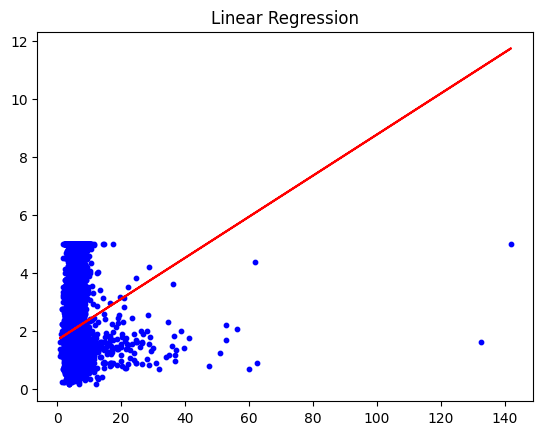

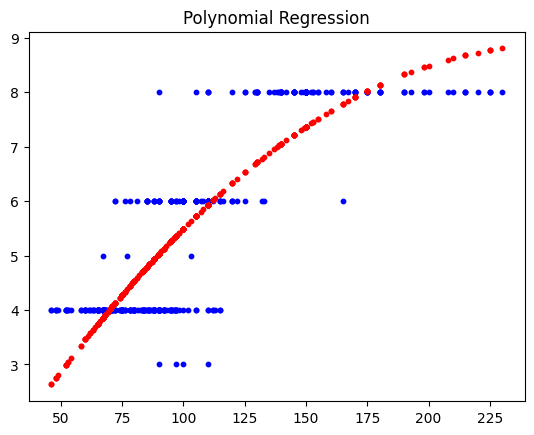

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import fetch_california_housing

df = fetch_california_housing(as_frame=True).frame
X,y = df[['AveRooms']], df['MedHouseVal']
model = LinearRegression().fit(X,y)
plt.scatter(X,y,s=10,c='b')
plt.plot(X,model.predict(X),c='r')
plt.title("Linear Regression")
plt.show()

url="https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
cols=["mpg","c","disp","hp","wt","acc","yr","orig"]
df2=pd.read_csv(url,sep='\s+',names=cols,na_values="?").dropna()
X2,y2 = df2[['disp']], df2['mpg']
X_poly = PolynomialFeatures(2).fit_transform(X2)
model2 = LinearRegression().fit(X_poly,y2)

plt.scatter(X2,y2,s=10,c='b')
plt.scatter(X2,model2.predict(X_poly),s=10,c='r')
plt.title("Polynomial Regression")
plt.show()

8. Develop a program to demonstrate the working of the decision tree algorithm. Use Breast Cancer Data set for building the decision tree and apply this knowledge to classify a new sample.

Prediction: malignant


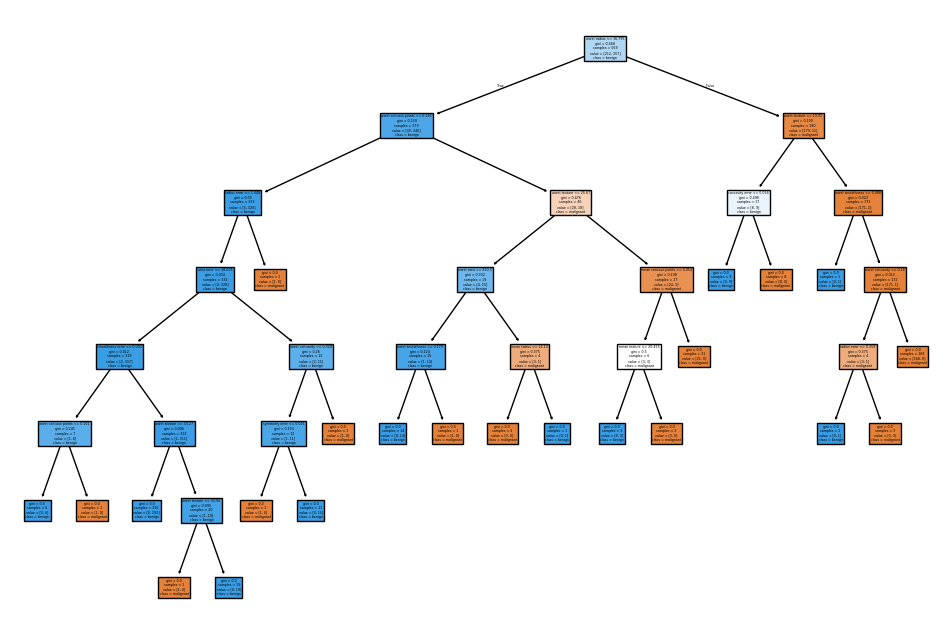

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree

data = load_breast_cancer()
X,y = data.data, data.target
clf = DecisionTreeClassifier().fit(X,y)
pred = clf.predict(X[:1])
print("Prediction:",data.target_names[pred[0]])

plt.figure(figsize=(12,8))
plot_tree(clf,feature_names=data.feature_names,class_names=data.target_names,filled=True)
plt.show()

9. Develop a program to implement the Naive Bayesian classifier considering Olivetti Face Data set for training. Compute the accuracy of the classifier, considering a few test data sets.

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Accuracy: 77.5


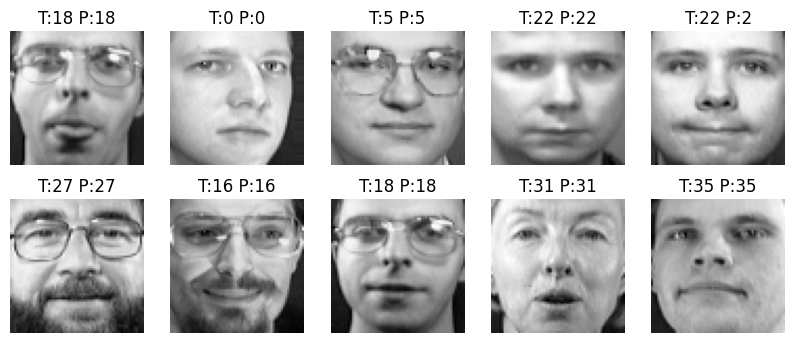

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X,y = faces.data, faces.target
X_tr,X_ts,y_tr,y_ts = train_test_split(X,y,test_size=0.2,random_state=42)

model = GaussianNB().fit(X_tr,y_tr)
pred = model.predict(X_ts)
print("Accuracy:",model.score(X_ts,y_ts)*100)

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_ts[i].reshape(64,64),cmap='gray')
    plt.title(f"T:{y_ts[i]} P:{pred[i]}")
    plt.axis('off')
plt.show()

10. Develop a program to implement k-means clustering using Wisconsin Breast Cancer data set and visualize the clustering result.

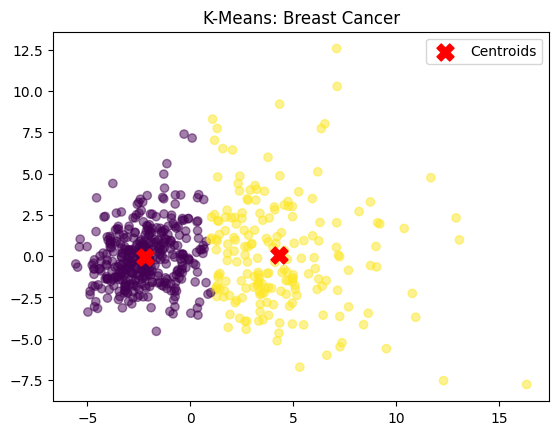

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = load_breast_cancer()
X = data.data
X_sc = StandardScaler().fit_transform(X)
km = KMeans(n_clusters=2,n_init=10,random_state=42)
y_km = km.fit_predict(X_sc)

pca = PCA(n_components=2)
X_p = pca.fit_transform(X_sc)
ctr = pca.transform(km.cluster_centers_)
plt.scatter(X_p[:,0],X_p[:,1],c=y_km,alpha=0.5)
plt.scatter(ctr[:,0],ctr[:,1],c='red',marker='X',s=150,label='Centroids')
plt.title("K-Means: Breast Cancer")
plt.legend()
plt.show()